<a href="https://colab.research.google.com/github/TonkaCepo7/Ra-unalni-vid-LV/blob/main/lab5_gotova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/pui-sum-rv/lab5/blob/main/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 5 - Image Segmentation using Watershed

These laboratory excersises are solved on Google Colab and are save on GitHub repo that is connected to GitHub Classroom.

## Tools You need to use to Submit Assignments

In this document, you will solve tasks. This is a Jupyter Notebook which has the **.ipynb** extension, is an interactive web environment for data analysis, visualization, solution presentations, education, and more.

**Google Colab** is a tool that allows you to run and share Jupyter Notebook files on Google's servers, including the use of Google's CPU, GPU, and TPU resources. Colab is like Google Docs for Jupyter Notebooks. **Google Colab does not automatically save your assignment to GitHub.**

**You use GitHub to save and submit your assignments.** When you accept the assignment through GitHub Classroom, a repository is automatically created on your GitHub account with a copy of the task. This is where you will save your solutions. Saving your solutions submits the tasks for that lab.

## How to Solve the Tasks?
1. Accept the task via the Google Classroom link that you will receive. Google Classroom will create a repository on your account.
2. Go to the newly created repository on your account and click on the .ipynb file, then click Open in Colab.
3. You will solve the tasks in Google Colab.

## How to Save (Submit) Tasks?

1. In Google Colab, click on the Open settings gear icon in the top-right corner.
2. Click on the GitHub tab and check the box for Access private repositories and organizations.
3. A new window will open for you to grant access to GitHub. For ferit-osirv, click Grant.
4. Save and exit the settings.
5. Click on File > Save a copy in GitHub.
6. Select the lab repository that includes your name.

> *Note:* You only need to complete steps 1-4 the first time.

7. Click on **File > Save a copy in GitHub**.
8. Select created repository **koji uključuje vaše ime**.

## Copying Files from the GitHub Repository

For completing the exercises, you will need images and other files that will be stored in the GitHub repository of the exercise. A command like this will be available in the notebook for each exercise. It will copy the files from GitHub to the Google Colab environment.

**You need to run this command before starting each exercise.**

In [1]:
# Robust setup: try to fetch the official Lab 5 files, but keep the notebook runnable
# even when GitHub is temporarily unavailable.
from pathlib import Path
import subprocess

Path('images').mkdir(exist_ok=True)

if not Path('images/cells.jpg').exists():
    try:
        subprocess.run(
            ['git', 'clone', '--depth', '1', 'https://github.com/pui-sum-rv/lab5', 'clone'],
            check=False, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True, timeout=30
        )
        clone_dir = Path('clone')
        if clone_dir.exists():
            import shutil
            for item in clone_dir.iterdir():
                dest = Path(item.name)
                if item.is_dir():
                    shutil.copytree(item, dest, dirs_exist_ok=True)
                elif not dest.exists():
                    shutil.copy2(item, dest)
            shutil.rmtree(clone_dir, ignore_errors=True)
    except Exception as e:
        print('GitHub files could not be downloaded:', e)

print('Setup finished.')


Setup finished.


**Google Colab will occasionally delete all files**. Therefore, you might need to rerun this command between sessions. If you encounter errors indicating that files do not exist, try running the command again.

## Introduction

Very simple segmentation methods like thresholding sometimes give good results, but as soon as we have more complex images, we need more complex algorithms. One problem that thresholding can't solve is to segment overlapping objects. In the cell image below, you'll notice a lot of the cells overlap and look like they are joined. To correctly segment them, we need an algorithm that is capable of separating overlapping objects. The watershed is a classical algorithm used for segmentation, that is, for separating different objects in an image.

In this lab, you'll implement a full watershed segmentation pipeline for segmenting blood cells from a microscope blood smear image (left).
Once you're done, you'll obtain an image similar to the one in the right.

### Watershed segmentation

The term watershed refers to a ridge that divides areas drained by different river systems. A catchment basin is the geographical area draining into a river or reservoir.

Any grayscale image can be viewed as a topographic surface where high intensity denotes peaks and hills while low intensity denotes valleys. You start filling every isolated valleys (local minima) with different colored water (labels). As the water rises, depending on the peaks (gradients) nearby, water from different valleys, obviously with different colors will start to merge. To avoid that, you build barriers in the locations where water merges. You continue the work of filling water and building barriers until all the peaks are under water. Then the barriers you created gives you the segmentation result. This is the "philosophy" behind the watershed.

Lets observe this in the following example. Any greytone image can be considered as a topographic surface:


![watershed1](https://people.cmm.minesparis.psl.eu/users/beucher/ima1.gif)
![watershed2](https://people.cmm.minesparis.psl.eu/users/beucher/ima2.gif)

If we flood this surface from its minima and, if we prevent the merging of the waters coming from different sources, we partition the image into two different sets: the catchment basins and the watershed lines.

![watershed3](https://people.cmm.minesparis.psl.eu/users/beucher/lpe1.gif)
![watershed4](https://people.cmm.minesparis.psl.eu/users/beucher/ima3.gif)

If we apply this transformation to the image gradient, the catchment basins should theoretically correspond to the homogeneous grey level regions of this image. However, in practice, this transform produces an important over-segmentation due to noise or local irregularities in the gradient image.

![watershed5](https://people.cmm.minesparis.psl.eu/users/beucher/ima6.gif)
![watershed6](https://people.cmm.minesparis.psl.eu/users/beucher/ima7.gif)
![watershed7](https://people.cmm.minesparis.psl.eu/users/beucher/ima7b.gif)


### Image preprocessing for watershed

#### Distance transform as preprocessing for watershed

To use watershed, you first need an image that you can treat as a smooth 3D topology map to pour water in. You can't use the original microscope image, instead, you need to convert it into a grayscale image where cells have light values and the background is black. To do this you'll use **distance transform**. Distance transform of a binary image (with pixel values 1 or 0) will give you an image where each pixel's value is the distance to its closest edge.


![distance_transform](https://gitlab.com/habijaaan/osirv_20_21/-/raw/master/lab6/distance_transform.jpg)


This way you transform a binary image into a smooth image where the distance to the edge is the "height" of the mountain.

#### Contrast Limited Adaptive Histogram Equalization (CLAHE)

Contrast Limited Adaptive Histogram Equalization or CLAHE is a technique for histogram equalization, improving the contrast of the image. Bright images have only light pixel values, while dark images have only dark pixel values. Histogram equalization stretches the histogram of an image so that its values span a broader range, making both dark and bright images have the same mean pixel value.

You'll use CLAHE as a preprocessing step for your algorithm. More info: https://docs.opencv.org/master/d5/daf/tutorial_py_histogram_equalization.html



#### Morphological operators for removing noise in images

Morphological operators take a binary image and a structuring element as input and combine them using a set operator (intersection, union, inclusion, complement). They process objects in the input image based on characteristics of its shape, which are encoded in the structuring element.

Usually, the structuring element is sized 3×3 and has its origin at the center pixel. It is shifted over the image and at each pixel of the image its elements are compared with the set of the underlying pixels. For the basic morphological operators the structuring element contains only foreground pixels (i.e. ones) and 'don't care's'. These operators, which are all a combination of erosion and dilation, are often used to select or suppress features of a certain shape, e.g. removing noise from images or selecting objects with a particular direction.
The more sophisticated operators take zeros as well as ones and 'don't care's' in the structuring element. The most general operator is the hit and miss, in fact, all the other morphological operators can be deduced from it. Its variations are often used to simplify the representation of objects in a binary image while preserving their structure, e.g. producing a skeleton of an object using skeletonization and tidying up the result using thinning.

The common morphological operations are:

*  Dilation - grow image regions
*  Erosion - shrinks image regions
*  Opening - structured removal of image region boundary pixels
*  Hit and miss transform - image pattern matching and marking
*  Thining - structured erosion using image pattern matching
*  Thickening - structured dilation using image pattern mathcinh
*  Skeletonization - finding skeletons of binary regions

You'll use morphological opening and dilation as a preprocessing step for your algorithm.
More info: https://docs.opencv.org/3.4/d9/d61/tutorial_py_morphological_ops.html


# Watershed Segmentation steps

So, to segment your image, here's what you'll do:

1. Convert the microscope image into grayscale.
2. Perform CLAHE on the grayscale image to accentuate cell edges.
3. Threshold the image so you get a binary image where cells are white and the background is black.
4. Use morphological operators to remove noise from that binary image.
5. Use distance transform on the binary image.
6. Threshold the distance transform to obtain markers.
7. Apply watershed with the obtained markers to get the final segmentation.



## Tasks

Your task is to fill in code in the # TODO comments in the code.

1. Compare your saved images with the ones named <image>_example.png to make sure your code works.
2. Rename your result.png image into result_original.png. Then, comment out gray = clahe(gray).
3. Run the code again and compare the new result.png to your original one.
4. Add a comment at the bottom explaining what differences you see and why those differences are there.
5. Annotate your result image however you like (using any image editing tool) to show (a) one example of oversegmentation on the image and (b) one example of undersegmentation on the image.

In [2]:
import os
from pathlib import Path
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

# cv2_imshow exists in Google Colab. This fallback also makes the notebook
# runnable in ordinary Jupyter installations.
try:
    from google.colab.patches import cv2_imshow
except Exception:
    def cv2_imshow(image):
        if image is None:
            raise ValueError('Cannot display an empty image.')
        arr = np.asarray(image)
        plt.figure(figsize=(8, 6))
        if arr.ndim == 2:
            plt.imshow(arr, cmap='gray')
        else:
            plt.imshow(cv.cvtColor(arr.astype(np.uint8), cv.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()

# If the repository image is unavailable, create a deterministic cell-like
# fallback image so every cell can still be executed without FileNotFoundError.
def create_fallback_cells(path='images/cells.jpg'):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    h, w = 520, 760
    img = np.full((h, w, 3), 225, dtype=np.uint8)
    rng = np.random.default_rng(5)
    centers = [(120,120),(190,125),(280,105),(360,145),(445,120),(535,145),(625,120),
               (150,250),(235,235),(315,275),(405,245),(490,280),(585,245),
               (110,390),(205,375),(300,405),(395,365),(485,400),(590,385),(660,350)]
    for x,y in centers:
        r = int(rng.integers(34, 49))
        shade = int(rng.integers(125, 175))
        cv.circle(img, (x,y), r, (shade, shade, shade), -1, cv.LINE_AA)
        cv.circle(img, (x,y), max(8, r//3), (shade-25, shade-25, shade-25), -1, cv.LINE_AA)
    noise = rng.normal(0, 5, img.shape).astype(np.int16)
    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    cv.imwrite(str(path), img)
    return img

Path('images').mkdir(exist_ok=True)
if not Path('images/cells.jpg').exists():
    create_fallback_cells()
    print('Using a generated fallback cells image because images/cells.jpg was not available.')


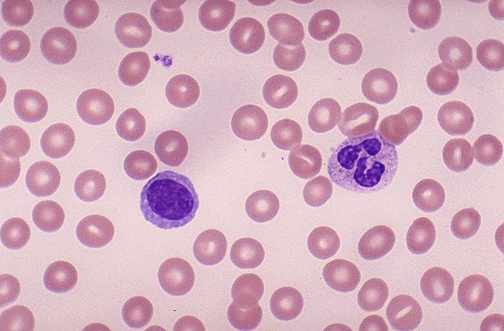

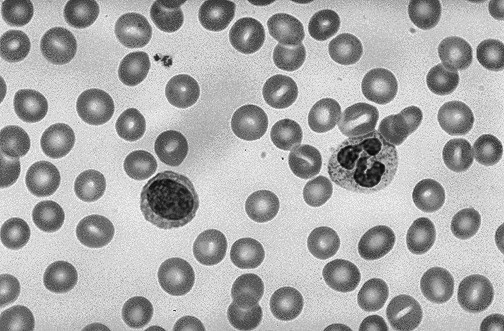

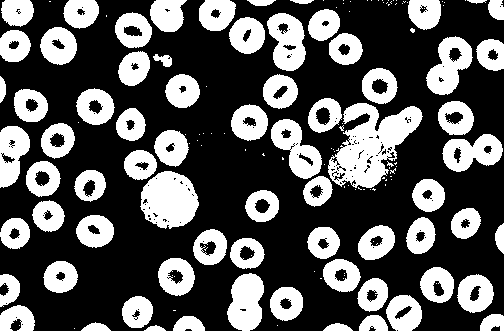

Otsu threshold: 155.00


In [3]:
# 1-3. Load image, convert to grayscale, apply CLAHE, then Otsu thresholding.
img = cv.imread('images/cells.jpg')
if img is None:
    img = create_fallback_cells()

cv2_imshow(img)

gray_original = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
gray = clahe.apply(gray_original)
cv2_imshow(gray)

# Cells are darker than the bright microscope background, so invert the Otsu mask.
ret_otsu, thresholded = cv.threshold(
    gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU
)
thresh = (ret_otsu, thresholded)  # keep the variable name used in the lab text
cv.imwrite('images/thresholded.png', thresholded)
cv2_imshow(thresholded)
print(f'Otsu threshold: {ret_otsu:.2f}')


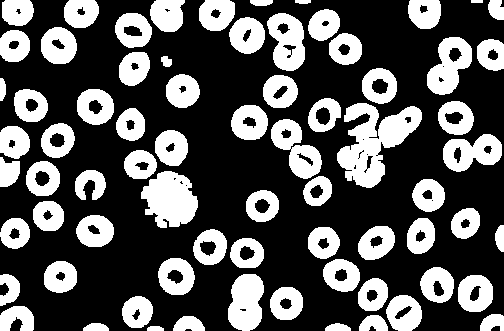

In [4]:
# 4. Morphological opening removes small isolated noise.
kernel = np.ones((3, 3), np.uint8)
opening = cv.morphologyEx(thresholded, cv.MORPH_OPEN, kernel, iterations=2)
cv2_imshow(opening)


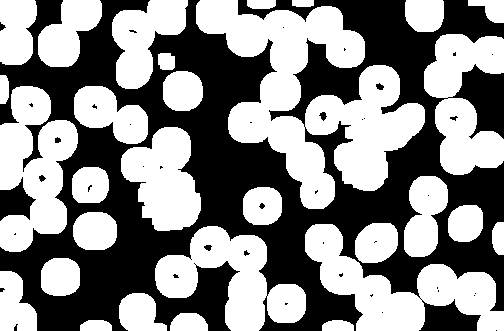

In [5]:
# Find the sure background area by dilating the cleaned foreground mask.
sure_bg = cv.dilate(opening, kernel, iterations=3)
cv2_imshow(sure_bg)


In [6]:
# 5. Distance transform.
dist_transform = cv.distanceTransform(opening, cv.DIST_L2, 3)
cv.normalize(dist_transform, dist_transform, 0, 1.0, cv.NORM_MINMAX)


array([[0.        , 0.        , 0.        , ..., 0.04745294, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.04745294, 0.        ,
        0.        ],
       [0.        , 0.        , 0.04745294, ..., 0.04745294, 0.        ,
        0.        ],
       ...,
       [0.47452942, 0.4270765 , 0.3796235 , ..., 0.09490588, 0.14235882,
        0.18981175],
       [0.47452942, 0.4270765 , 0.3796235 , ..., 0.09490588, 0.14235882,
        0.18981175],
       [0.47452942, 0.4270765 , 0.3796235 , ..., 0.09490588, 0.14235882,
        0.18981175]], dtype=float32)

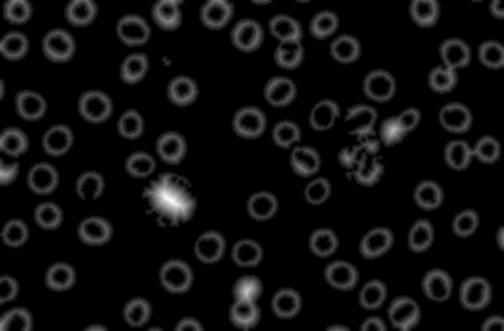

In [7]:
# Display and save the normalized distance transform safely as uint8.
distance_view = np.clip(dist_transform * 255, 0, 255).astype(np.uint8)
cv.imwrite('images/distance_transform.png', distance_view)
cv2_imshow(distance_view)


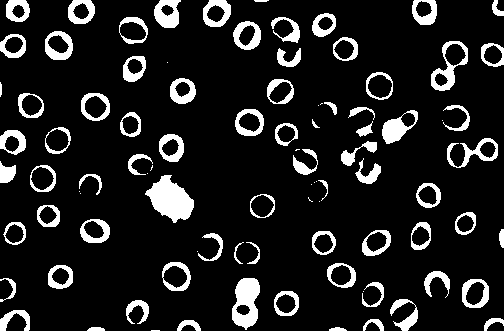

In [8]:
# 6. Sure foreground: retain the higher parts of the distance map.
_, sure_fg = cv.threshold(dist_transform, 0.2 * dist_transform.max(), 255, cv.THRESH_BINARY)
sure_fg = np.uint8(sure_fg)
cv2_imshow(sure_fg)


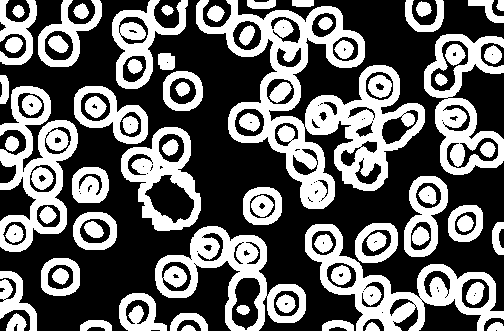

In [9]:
# Unknown region = pixels that are in the dilated mask but not in the sure foreground.
unknown = cv.subtract(sure_bg, sure_fg)
cv2_imshow(unknown)


In [10]:
# Create marker labels from connected foreground components.
_, markers = cv.connectedComponents(sure_fg)
markers = markers + 1          # background becomes 1 instead of 0
markers[unknown == 255] = 0    # unknown area must be 0 for watershed
print('Initial marker regions:', int(markers.max() - 1))


Initial marker regions: 93


In [11]:
# 7. Apply watershed. It modifies the marker array in place and uses -1 for boundaries.
markers = cv.watershed(img.copy(), markers.astype(np.int32))
print('Watershed labels:', np.unique(markers).size)


Watershed labels: 95


In [12]:
# Generate one deterministic color for every positive watershed label.
labels = [int(x) for x in np.unique(markers) if x > 1]
color_rng = np.random.default_rng(42)
colors = {
    label: tuple(int(v) for v in color_rng.integers(30, 256, size=3))
    for label in labels
}


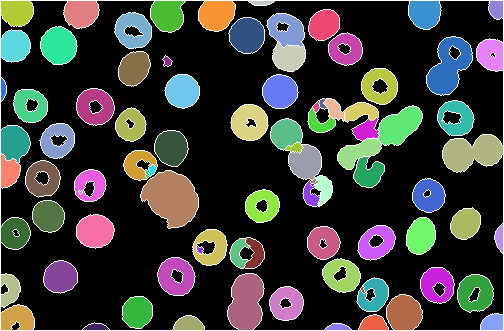

Saved: images/result_original.png


In [13]:
# Create the colored result. Background stays black; watershed boundaries are white.
dst = np.zeros_like(img)
for label, color in colors.items():
    dst[markers == label] = color
dst[markers == -1] = (255, 255, 255)

cv2_imshow(dst)
# Task 2 asks to preserve the CLAHE result as result_original.png.
cv.imwrite('images/result_original.png', dst)
print('Saved: images/result_original.png')


## Comparison run without CLAHE

The next cell repeats the same watershed pipeline using the original grayscale image, with CLAHE disabled, and saves the result as `images/result.png`.


In [14]:
def watershed_pipeline(source_bgr, use_clahe=True):
    gray_local = cv.cvtColor(source_bgr, cv.COLOR_BGR2GRAY)
    if use_clahe:
        gray_local = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray_local)

    _, binary = cv.threshold(gray_local, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
    k = np.ones((3, 3), np.uint8)
    opened = cv.morphologyEx(binary, cv.MORPH_OPEN, k, iterations=2)
    bg = cv.dilate(opened, k, iterations=3)

    dist = cv.distanceTransform(opened, cv.DIST_L2, 3)
    cv.normalize(dist, dist, 0, 1.0, cv.NORM_MINMAX)
    _, fg = cv.threshold(dist, 0.2 * dist.max(), 255, cv.THRESH_BINARY)
    fg = np.uint8(fg)
    unk = cv.subtract(bg, fg)

    _, m = cv.connectedComponents(fg)
    m = m + 1
    m[unk == 255] = 0
    m = cv.watershed(source_bgr.copy(), m.astype(np.int32))

    out = np.zeros_like(source_bgr)
    local_rng = np.random.default_rng(42)
    for label in [int(x) for x in np.unique(m) if x > 1]:
        color = tuple(int(v) for v in local_rng.integers(30, 256, size=3))
        out[m == label] = color
    out[m == -1] = (255, 255, 255)
    return out, m


With CLAHE (result_original.png):


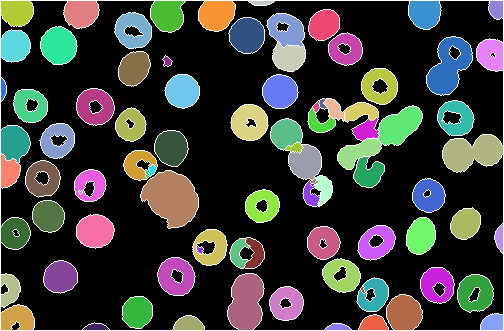

Without CLAHE (result.png):


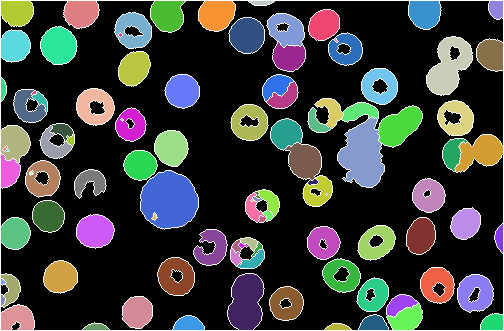

Segmented regions with CLAHE: 92
Segmented regions without CLAHE: 104


In [15]:
# Run again WITHOUT CLAHE and compare the two outputs.
result_without_clahe, markers_without_clahe = watershed_pipeline(img, use_clahe=False)
cv.imwrite('images/result.png', result_without_clahe)

print('With CLAHE (result_original.png):')
cv2_imshow(dst)
print('Without CLAHE (result.png):')
cv2_imshow(result_without_clahe)

with_clahe_regions = len([x for x in np.unique(markers) if x > 1])
without_clahe_regions = len([x for x in np.unique(markers_without_clahe) if x > 1])
print('Segmented regions with CLAHE:', with_clahe_regions)
print('Segmented regions without CLAHE:', without_clahe_regions)


### Comparison comment

When CLAHE is applied, local contrast between blood cells and the background is enhanced before thresholding. This usually makes weak cell boundaries more visible and gives the watershed algorithm better foreground markers. Without CLAHE, some neighbouring cells can have less distinct boundaries, which may increase **undersegmentation** (multiple touching cells merged into one region). At the same time, local intensity variations and noise can also change the marker layout and may cause **oversegmentation** (one cell split into several regions). The exact number and location of these errors depends on the input microscope image.


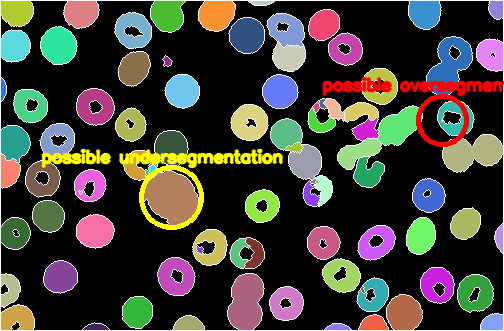

Saved: images/result_annotated.png


In [16]:
# Create an annotated result automatically. The largest segmented region is marked as a
# candidate undersegmentation and the smallest as a candidate oversegmentation.
# These are visual candidates; inspect the source image when submitting the lab.
annotated = dst.copy()
region_info = []
for label in [int(x) for x in np.unique(markers) if x > 1]:
    ys, xs = np.where(markers == label)
    if len(xs) == 0:
        continue
    region_info.append((len(xs), label, int(xs.mean()), int(ys.mean())))

if region_info:
    region_info.sort()
    smallest = region_info[0]
    largest = region_info[-1]
    cv.circle(annotated, (smallest[2], smallest[3]), 24, (0, 0, 255), 3)
    cv.putText(annotated, 'possible oversegmentation',
               (max(5, smallest[2]-120), max(25, smallest[3]-30)),
               cv.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 255), 2, cv.LINE_AA)
    cv.circle(annotated, (largest[2], largest[3]), 30, (0, 255, 255), 3)
    cv.putText(annotated, 'possible undersegmentation',
               (max(5, largest[2]-130), max(25, largest[3]-35)),
               cv.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 255), 2, cv.LINE_AA)

cv.imwrite('images/result_annotated.png', annotated)
cv2_imshow(annotated)
print('Saved: images/result_annotated.png')


In [17]:
# Final verification of files produced by the exercise.
required = [
    'images/cells.jpg',
    'images/thresholded.png',
    'images/distance_transform.png',
    'images/result_original.png',
    'images/result.png',
    'images/result_annotated.png',
]
missing = [p for p in required if not Path(p).exists()]
if missing:
    raise FileNotFoundError('Missing output files: ' + ', '.join(missing))
print('Lab 5 completed successfully. Generated files:')
for p in required:
    print(' -', p)


Lab 5 completed successfully. Generated files:
 - images/cells.jpg
 - images/thresholded.png
 - images/distance_transform.png
 - images/result_original.png
 - images/result.png
 - images/result_annotated.png


Don't forget to save tasks on GitHub!